<a href="https://colab.research.google.com/github/AISHIK1/Image-Classifiers/blob/main/Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import tensorflow as tf
from tensorflow import keras
from keras.applications.resnet50 import ResNet50,decode_predictions
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
import numpy as np

In [3]:
model=ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [4]:
import cv2

In [17]:
from keras.applications.convnext import preprocess_input
from tensorflow.keras.preprocessing import image
img_path='/content/dog.0.jpg'
img=image.load_img(img_path,target_size=(224,224))
X=image.img_to_array(img)
X=np.expand_dims(X,axis=0)
X=preprocess_input(X)

In [12]:
X.shape

(1, 256, 256, 3)

In [18]:
preds=model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [28]:

print(decode_predictions(preds)[0])

[('n02088094', 'Afghan_hound', np.float32(0.47518715)), ('n02102318', 'cocker_spaniel', np.float32(0.3734973)), ('n02101006', 'Gordon_setter', np.float32(0.05165287)), ('n02102480', 'Sussex_spaniel', np.float32(0.017185315)), ('n02113624', 'toy_poodle', np.float32(0.012452011))]


In [29]:
import os

os.environ['KAGGLE_USERNAME'] = 'aishik996'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_61236d6a08ac73ba31896583260ad688'

In [30]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [01:07<00:00, 16.9MB/s]



In [31]:
import zipfile

with zipfile.ZipFile('dogsvscats.zip','r')as zip_ref:
  zip_ref.extractall('data')

In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from keras.applications.vgg16 import VGG16

In [33]:
conv_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [36]:
model=Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [38]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,828,609 (64.20 MB)

 Trainable params: 16,828,609 (64.20 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
conv_base.trainable=False

In [40]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/data/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150,150)
)

test_ds=keras.utils.image_dataset_from_directory(
    directory='/content/data/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(150,150)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [43]:
model.fit(train_ds,epochs=15,validation_data=(test_ds))

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9402 - loss: 0.1630 - val_accuracy: 0.9516 - val_loss: 0.1180
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9475 - loss: 0.1637 - val_accuracy: 0.9540 - val_loss: 0.1177
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9503 - loss: 0.1364 - val_accuracy: 0.9522 - val_loss: 0.1246
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9562 - loss: 0.1137 - val_accuracy: 0.9532 - val_loss: 0.1264
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9597 - loss: 0.1097 - val_accuracy: 0.9576 - val_loss: 0.1193
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9635 - loss: 0.1043 - val_accuracy: 0.9540 - val_loss: 0.1266
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9646 - loss: 0.1054 - val_accuracy: 0.9596 - val_loss: 0.1189
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9673 - loss: 0.0975 - 

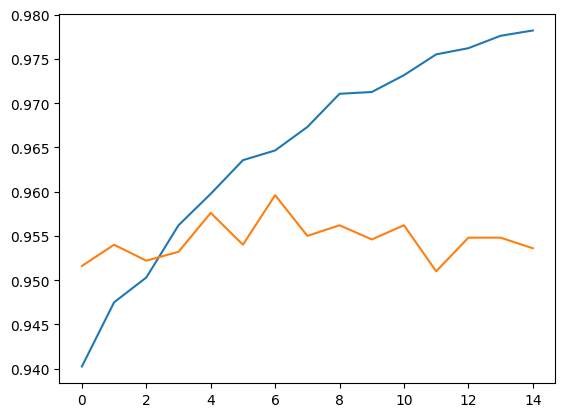

In [46]:
import matplotlib.pyplot as plt

plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

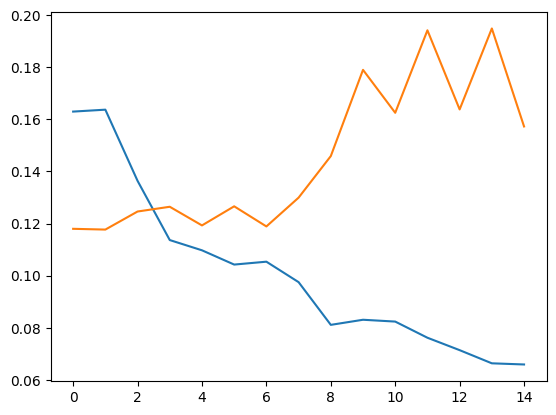

In [47]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

In [48]:
print(conv_base.layers)

[<InputLayer name=input_layer_1, built=True>, <Conv2D name=block1_conv1, built=True>, <Conv2D name=block1_conv2, built=True>, <MaxPooling2D name=block1_pool, built=True>, <Conv2D name=block2_conv1, built=True>, <Conv2D name=block2_conv2, built=True>, <MaxPooling2D name=block2_pool, built=True>, <Conv2D name=block3_conv1, built=True>, <Conv2D name=block3_conv2, built=True>, <Conv2D name=block3_conv3, built=True>, <MaxPooling2D name=block3_pool, built=True>, <Conv2D name=block4_conv1, built=True>, <Conv2D name=block4_conv2, built=True>, <Conv2D name=block4_conv3, built=True>, <MaxPooling2D name=block4_pool, built=True>, <Conv2D name=block5_conv1, built=True>, <Conv2D name=block5_conv2, built=True>, <Conv2D name=block5_conv3, built=True>, <MaxPooling2D name=block5_pool, built=True>]


In [56]:
set_trainable=False
conv_base.trainable=True
for layer in conv_base.layers:
  if layer.name=='block5_conv1':
    set_trainable=True
  if set_trainable:
    layer.trainable=True
  else:
    layer.trainable=False

for name in conv_base.layers:
  print(name.name,name.trainable)

input_layer_1 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [76]:
model=Sequential()
model.add(conv_base)

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [69]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 2, 2, 32)       │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,911,713 (56.88 MB)

 Trainable params: 7,276,449 (27.76 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [77]:
model.fit(train_ds,epochs=15,validation_data=(test_ds))

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.4958 - loss: 1.0946 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4931 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4961 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5085 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4960 - loss: 0.6935 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.5023 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4915 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.4975 - loss: 0.6932 - 

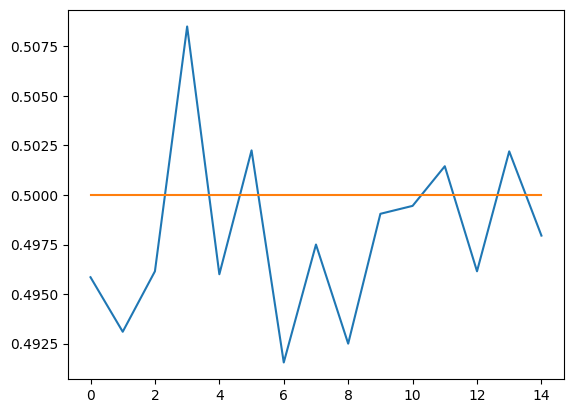

In [78]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

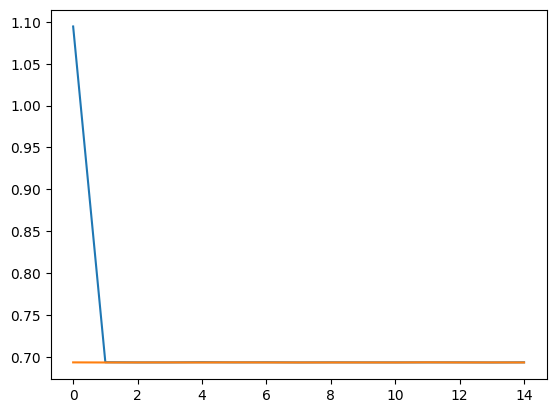

In [79]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])